In [3]:

from dolfinx import log, default_scalar_type
from dolfinx.fem.petsc import NonlinearProblem
import numpy as np
from dolfinx.io.gmsh import read_from_msh
import ufl
import gmsh
from mpi4py import MPI
from dolfinx import fem, mesh, plot
def facets_to_nodes(domain, facet_ids):
    fdim = domain.topology.dim - 1
    domain.topology.create_connectivity(fdim, 0)
    facet_to_vertices = domain.topology.connectivity(fdim, 0)
    all_nodes = []
    for f in facet_ids:
        all_nodes.extend(facet_to_vertices.links(f))
    return np.unique(np.array(all_nodes, dtype=np.int32))
def FEM_solve(load_parameter, elastic_modulus, poisson_ratio) :
    gmsh.initialize()
    gdim = 2
    model = gmsh.model.occ
    L_x = 1.0
    L_y = 1.0
    R_hole = 0.1
    mesh_size = 0.02
    load_parameter = load_parameter
    # 2. Create rectangle
    rect = model.addRectangle(0.0, 0.0, 0.0, L_x, L_y)

    # 3. Create circle
    circle = model.addDisk(0.0, 0.0, 0.0, R_hole, R_hole)

    # 4. Cut the hole
    domain_with_hole, _ = model.cut([(gdim, rect)], [(gdim, circle)])
    gmsh.model.occ.synchronize()

    # 5. Physical group
    gmsh.model.addPhysicalGroup(gdim, [rect], 1)
    gmsh.model.setPhysicalName(gdim, 1, "domain")
    gmsh.option.setNumber("Mesh.CharacteristicLengthMin", mesh_size)
    gmsh.option.setNumber("Mesh.CharacteristicLengthMax", mesh_size)
    gmsh.model.mesh.generate(gdim)
    # 6. Mesh generation
    gmsh.model.mesh.generate(gdim)

    # 7. Write to file
    gmsh.write("mesh.msh")
    gmsh.finalize()

    # 8. Read into DOLFINx
    mesh_ = read_from_msh("mesh.msh", MPI.COMM_WORLD, 0, gdim)
    domain = mesh_.mesh
    V = fem.functionspace(domain, ("Lagrange", 1, (domain.geometry.dim,)))


    # -

    # We create two python functions for determining the facets to apply boundary conditions to


    # +
    def left(x):
        return np.isclose(x[0], 0)


    def right(x):
        return np.isclose(x[0], L_x)


    def top(x):
        return np.isclose(x[1], L_y)


    def bottom(x):
        return np.isclose(x[1], 0)


    fdim = domain.topology.dim - 1
    left_facets = mesh.locate_entities_boundary(domain, fdim, left)
    right_facets = mesh.locate_entities_boundary(domain, fdim, right)
    top_facets = mesh.locate_entities_boundary(domain, fdim, top)
    bottom_facets = mesh.locate_entities_boundary(domain, fdim, bottom)
    # -

    # Next, we create a  marker based on these two functions

    # Concatenate and sort the arrays based on facet indices. Left facets marked with 1, right facets with two

    marked_facets = np.hstack([left_facets, bottom_facets, right_facets, top_facets])
    marked_values = np.hstack([np.full_like(left_facets, 1), np.full_like(bottom_facets, 2), np.full_like(right_facets, 3), np.full_like(top_facets, 4)])
    sorted_facets = np.argsort(marked_facets)
    facet_tag = mesh.meshtags(
        domain, fdim, marked_facets[sorted_facets], marked_values[sorted_facets]
    )

    # We then create a function for supplying the boundary condition on the left side, which is fixed.

    u_bc = np.array((0,) * domain.geometry.dim, dtype=default_scalar_type)

    # To apply the boundary condition, we identity the dofs located on the facets marked by the `MeshTag`.
    zero = fem.Constant(domain, default_scalar_type(0.0))
    control_ux = fem.Constant(domain, default_scalar_type(load_parameter/2))
    control_uy = fem.Constant(domain, default_scalar_type(load_parameter))

    # Locate DOFs (note the use of collapsed spaces)
    left_dofs = fem.locate_dofs_topological(V.sub(0), facet_tag.dim, facet_tag.find(1))
    bottom_dofs = fem.locate_dofs_topological(V.sub(1), facet_tag.dim, facet_tag.find(2))
    right_dofs = fem.locate_dofs_topological(V.sub(0), facet_tag.dim, facet_tag.find(3))
    top_dofs = fem.locate_dofs_topological(V.sub(1), facet_tag.dim, facet_tag.find(4))
    bcs = [fem.dirichletbc(zero, left_dofs, V.sub(0)), 
        fem.dirichletbc(zero, bottom_dofs, V.sub(1)),
        fem.dirichletbc(control_ux, right_dofs, V.sub(0)),
        fem.dirichletbc(control_uy, top_dofs, V.sub(1))]

    # Next, we define the body force on the reference configuration (`B`), and nominal (first Piola-Kirchhoff) traction (`T`).

    B = fem.Constant(domain, default_scalar_type((0, 0)))
    T = fem.Constant(domain, default_scalar_type((0, 0)))

    # Define the test and solution functions on the space $V$

    v = ufl.TestFunction(V)
    u = fem.Function(V)

    # Define kinematic quantities used in the problem

    # +
    # Spatial dimension
    d = len(u)

    # Identity tensor
    I = ufl.variable(ufl.Identity(d))

    # Deformation gradient
    F = ufl.variable(I + ufl.grad(u))

    # Right Cauchy-Green tensor
    C = ufl.variable(F.T * F)

    # Invariants of deformation tensors
    Ic = ufl.variable(ufl.tr(C))
    J = ufl.variable(ufl.det(F))
    # -

    # Define the elasticity model via a stored strain energy density function $\psi$,
    # and create the expression for the first Piola-Kirchhoff stress:

    # Elasticity parameters

    E = default_scalar_type(elastic_modulus)
    nu = default_scalar_type(poisson_ratio)
    mu = fem.Constant(domain, E / (2 * (1 + nu)))
    lmbda = fem.Constant(domain, E * nu / ((1 + nu) * (1 - 2 * nu)))

    # Stored strain energy density (compressible neo-Hookean model)

    # psi = (mu / 2) * (Ic - 3) - mu * ufl.ln(J) + (lmbda / 2) * (ufl.ln(J)) ** 2

    psi = 0.5 * (J**(-2/3) * Ic - 3) + 1.5 * (J - 1)**2
    # Hyper-elasticity

    P = ufl.diff(psi, F)

    metadata = {"quadrature_degree": 4}
    ds = ufl.Measure("ds", domain=domain, subdomain_data=facet_tag, metadata=metadata)
    dx = ufl.Measure("dx", domain=domain, metadata=metadata)

    # Define the residual of the equation (we want to find u such that residual(u) = 0)

    residual = (
        ufl.inner(ufl.grad(v), P) * dx - ufl.inner(v, B) * dx - ufl.inner(v, T) * ds(3)
    )

    # As the varitional form is non-linear and written on residual form,
    # we use the non-linear problem class from DOLFINx to set up required structures to use a Newton solver.

    petsc_options = {
        "snes_type": "newtonls",
        "snes_linesearch_type": "none",
        "snes_monitor": None,
        "snes_atol": 1e-10,
        "snes_rtol": 1e-10,
        "snes_stol": 1e-10,
        "ksp_type": "preonly",
        "pc_type": "lu",
        "pc_factor_mat_solver_type": "mumps",
    }
    problem = NonlinearProblem(
        residual,
        u,
        bcs=bcs,
        petsc_options=petsc_options,
        petsc_options_prefix="hyperelasticity",
        
    )

    problem.solve()


    mesh_pos = domain.geometry.x
    fdim = domain.topology.dim - 1 
    domain.topology.create_connectivity(fdim, domain.topology.dim)
    cells = domain.topology.connectivity(domain.topology.dim, 0).array.reshape(-1, 3)
    u_array = u.x.array[:].reshape(mesh_pos.shape[0], -1)
    num_nodes = domain.geometry.x.shape[0]
    node_type = np.zeros(num_nodes, dtype=int)
    node_type[facets_to_nodes(domain, left_facets)] = 1
    node_type[facets_to_nodes(domain, bottom_facets)] = 2
    node_type[facets_to_nodes(domain, right_facets)] = 3
    node_type[facets_to_nodes(domain, top_facets)] = 4


    return dict(mesh_pos = mesh_pos, cells = cells, u = u_array, node_type = node_type, load_parameter = load_parameter)


In [4]:
data = FEM_solve(0.2, 1e4, 0.2)

Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Ellipse)
Info    : [ 30%] Meshing curve 2 (Line)
Info    : [ 50%] Meshing curve 3 (Line)
Info    : [ 70%] Meshing curve 4 (Line)
Info    : [ 90%] Meshing curve 5 (Line)
Info    : Done meshing 1D (Wall 0.00148184s, CPU 0.001208s)
Info    : Meshing 2D...
Info    : Meshing surface 1 (Plane, Frontal-Delaunay)
Info    : Done meshing 2D (Wall 0.0714437s, CPU 0.062953s)
Info    : 3010 nodes 6023 elements
Info    : Meshing 2D...
Info    : Meshing surface 1 (Plane, Frontal-Delaunay)
Info    : Done meshing 2D (Wall 0.0661418s, CPU 0.063538s)
Info    : 3010 nodes 6023 elements
Info    : Writing 'mesh.msh'...
Info    : Done writing 'mesh.msh'
Info    : Reading 'mesh.msh'...
Info    : 11 entities
Info    : 3010 nodes
Info    : 5820 elements
Info    : Done reading 'mesh.msh'
  0 SNES Function norm 7.278643993299e+00
  1 SNES Function norm 1.388077026767e-01
  2 SNES Function norm 1.762245475432e-01
  3 SNES Function norm 1.249324376937e-02
  

In [3]:
np.savez_compressed("/home/mmdiscovery/shared/dataset/NH/load0.5.npz", **data)

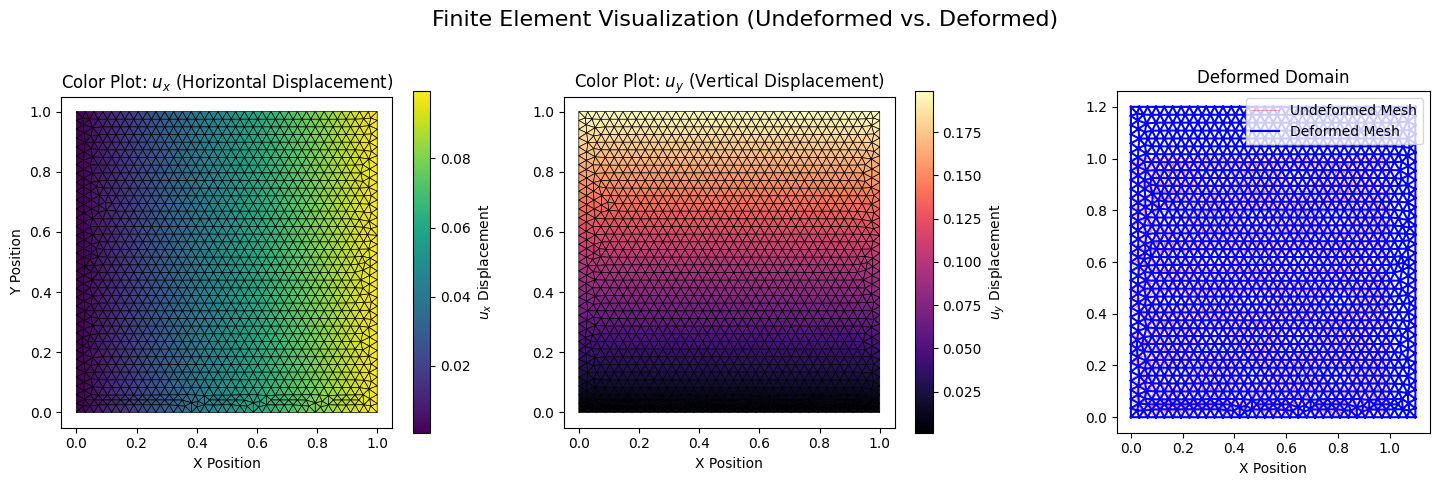

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as tri

# --- 1. Setup Dummy Data (Simulating FEM Output) ---
# Create a simple 2x2 rectangular mesh with 4 nodes and 2 triangular elements
# Node coordinates (Undeformed mesh_pos)
mesh_pos = data["mesh_pos"]

# Element connectivity (cells: indices of nodes forming each triangle)
cells = data["cells"]

# Displacement components (ux and uy) at each node
# This simulates a simple shear/tensile deformation
ux = data["u"][:, 0]
uy = data["u"][:, 1]

# Combine components into the full displacement vector u
u = np.column_stack((ux, uy))

# Calculate the deformed coordinates (world_pos)
world_pos = mesh_pos[:, :2] + u

# --- 2. Initialize Triangulation Objects ---
# We need the x and y coordinates from the undeformed mesh
x = mesh_pos[:, 0]
y = mesh_pos[:, 1]

# Create the Matplotlib Triangulation object
# This object stores the connectivity (cells) and coordinates (x, y)
triangulation = tri.Triangulation(x, y, cells)

# --- 3. Plotting ---

# Set up the figure with 1 row and 3 columns for the plots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Finite Element Visualization (Undeformed vs. Deformed)', fontsize=16)

# --- Subplot 1: Plotting UX (Horizontal Displacement) ---
ax1 = axes[0]
# tripcolor uses the triangulation to color the triangles based on the nodal value
# `facecolors` uses the average of the three nodal values per triangle for coloring
tpc1 = ax1.tripcolor(triangulation, ux, cmap='viridis', edgecolors='k', linewidth=0.5)
fig.colorbar(tpc1, ax=ax1, label='$u_x$ Displacement')
# ax1.scatter(mesh_pos[data["node_type"] == 5, 0], mesh_pos[node_type == 5, 1])
ax1.set_title('Color Plot: $u_x$ (Horizontal Displacement)')
ax1.set_xlabel('X Position')
ax1.set_ylabel('Y Position')
ax1.set_aspect('equal')

# --- Subplot 2: Plotting UY (Vertical Displacement) ---
ax2 = axes[1]
tpc2 = ax2.tripcolor(triangulation, uy, cmap='magma', edgecolors='k', linewidth=0.5)
fig.colorbar(tpc2, ax=ax2, label='$u_y$ Displacement')

ax2.set_title('Color Plot: $u_y$ (Vertical Displacement)')
ax2.set_xlabel('X Position')
ax2.set_aspect('equal')

# --- Subplot 3: Plotting Deformed Domain ---
ax3 = axes[2]

# Plot the outline of the UNDEFORMED mesh for reference (dashed gray)
ax3.triplot(triangulation, 'r-', alpha=0.5, linewidth=0.5, label='Undeformed Mesh')

# Plot the DEFORMED mesh. We must manually create a new triangulation
# object using the deformed coordinates (world_pos) but the SAME connectivity (cells).
x_def = world_pos[:, 0]
y_def = world_pos[:, 1]
tri_def = tri.Triangulation(x_def, y_def, cells)

# Plot the deformed mesh (solid blue lines)
ax3.triplot(tri_def, 'b-', linewidth=1.5, label='Deformed Mesh')

ax3.set_title('Deformed Domain')
ax3.set_xlabel('X Position')
ax3.legend()
ax3.set_aspect('equal')

# Adjust layout to prevent overlaps
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [ ]:

from dolfinx import log, default_scalar_type
from dolfinx.fem.petsc import NonlinearProblem
import numpy as np
from dolfinx.io.gmsh import read_from_msh
import ufl
import gmsh
from mpi4py import MPI
from dolfinx import fem, mesh, plot
def facets_to_nodes(domain, facet_ids):
    fdim = domain.topology.dim - 1
    domain.topology.create_connectivity(fdim, 0)
    facet_to_vertices = domain.topology.connectivity(fdim, 0)
    all_nodes = []
    for f in facet_ids:
        all_nodes.extend(facet_to_vertices.links(f))
    return np.unique(np.array(all_nodes, dtype=np.int32))
def FEM_solve(load_parameter, elastic_modulus, poisson_ratio) :
    gmsh.initialize()
    gdim = 2
    model = gmsh.model.occ
    L_x = 1.0
    L_y = 1.0
    R_hole = 0.1
    mesh_size = 0.03
    load_parameter = load_parameter
    # 2. Create rectangle
    rect = model.addRectangle(0.0, 0.0, 0.0, L_x, L_y)

    # 3. Create circle
    ellipses = [
        (0.375, 0.25, 0.25, 0.125),   # ellipse 1
        (0.75, 1 - 0.375, 0.125, 0.25),  # ellipse 2
    ]

    # ellipse_objs = []
    ellipse_faces = []
    for (cx, cy, rx, ry) in ellipses:
        
        if rx < ry :
            disk = model.addDisk(cx, cy, 0.0, ry, rx)  # make a filled 2D region
            model.rotate([(gdim, disk)], cx, cy, 0, 0, 0, 1, np.pi/2)
        else :
            disk = model.addDisk(cx, cy, 0.0, rx, ry)  # make a filled 2D region
        ellipse_faces.append((gdim, disk))
    # print(gdim, ellipse1)
    # --- Cut both ellipses from the rectangle ---
    domain_with_holes, _ = model.cut([(gdim, rect)], ellipse_faces)

    # --- Synchronize geometry ---
    model.synchronize()

    # 5. Physical group
    gmsh.model.addPhysicalGroup(gdim, [domain_with_holes[0][1]], 1)
    gmsh.model.setPhysicalName(gdim, 1, "domain")
    
    gmsh.option.setNumber("Mesh.CharacteristicLengthMin", mesh_size)
    gmsh.option.setNumber("Mesh.CharacteristicLengthMax", mesh_size)
    gmsh.model.mesh.generate(gdim)
    # 6. Mesh generation
    gmsh.model.mesh.setOrder(2)
    # 7. Write to file
    gmsh.write("mesh_with_hole_2ndOrder.msh")
    gmsh.finalize()

    # 8. Read into DOLFINx
    mesh_ = read_from_msh("mesh_with_hole.msh", MPI.COMM_WORLD, 0, gdim)
    domain = mesh_.mesh
    V = fem.functionspace(domain, ("Lagrange", 1, (domain.geometry.dim,)))


    # -

    # We create two python functions for determining the facets to apply boundary conditions to


    # +
    def left(x):
        return np.isclose(x[0], 0)


    def right(x):
        return np.isclose(x[0], L_x)


    def top(x):
        return np.isclose(x[1], L_y)


    def bottom(x):
        return np.isclose(x[1], 0)


    fdim = domain.topology.dim - 1
    left_facets = mesh.locate_entities_boundary(domain, fdim, left)
    right_facets = mesh.locate_entities_boundary(domain, fdim, right)
    top_facets = mesh.locate_entities_boundary(domain, fdim, top)
    bottom_facets = mesh.locate_entities_boundary(domain, fdim, bottom)
    # -

    # Next, we create a  marker based on these two functions

    # Concatenate and sort the arrays based on facet indices. Left facets marked with 1, right facets with two

    marked_facets = np.hstack([left_facets, bottom_facets, right_facets, top_facets])
    marked_values = np.hstack([np.full_like(left_facets, 1), np.full_like(bottom_facets, 2), np.full_like(right_facets, 3), np.full_like(top_facets, 4)])
    sorted_facets = np.argsort(marked_facets)
    facet_tag = mesh.meshtags(
        domain, fdim, marked_facets[sorted_facets], marked_values[sorted_facets]
    )

    # We then create a function for supplying the boundary condition on the left side, which is fixed.

    u_bc = np.array((0,) * domain.geometry.dim, dtype=default_scalar_type)

    # To apply the boundary condition, we identity the dofs located on the facets marked by the `MeshTag`.
    zero = fem.Constant(domain, default_scalar_type(0.0))
    # control_ux = fem.Constant(domain, default_scalar_type(load_parameter * 0))
    control_uy = fem.Constant(domain, default_scalar_type(0.1))

    # Locate DOFs (note the use of collapsed spaces)
    # left_dofs = fem.locate_dofs_topological(V.sub(0), facet_tag.dim, facet_tag.find(1))
    bottom_dofs = fem.locate_dofs_topological(V, facet_tag.dim, facet_tag.find(2))
    # bottom_y_dofs = fem.locate_dofs_topological(V.sub(1), facet_tag.dim, facet_tag.find(2))
    # right_dofs = fem.locate_dofs_topological(V.sub(0), facet_tag.dim, facet_tag.find(3))
    top_y_dof = fem.locate_dofs_topological(V.sub(1), facet_tag.dim, facet_tag.find(4))
    top_x_dof = fem.locate_dofs_topological(V.sub(0), facet_tag.dim, facet_tag.find(4))
    bcs = [
        fem.dirichletbc(u_bc, bottom_dofs, V),
        fem.dirichletbc(control_uy, top_y_dof, V.sub(1)),
        fem.dirichletbc(zero, top_x_dof, V.sub(0))
        ]

    # Next, we define the body force on the reference configuration (`B`), and nominal (first Piola-Kirchhoff) traction (`T`).

    B = fem.Constant(domain, default_scalar_type((0, 0)))
    T = fem.Constant(domain, default_scalar_type((0, 0)))

    # Define the test and solution functions on the space $V$

    v = ufl.TestFunction(V)
    u = fem.Function(V)

    # Define kinematic quantities used in the problem

    # +
    # Spatial dimension
    d = len(u)

    # Identity tensor
    I = ufl.variable(ufl.Identity(3))

    # Deformation gradient
    def grad_3D(u):
        return ufl.as_matrix([[u[0].dx(0), u[0].dx(1), 0], 
                            [u[1].dx(0), u[1].dx(1), 0], 
                            [0, 0, 0]])
    F = ufl.variable(I + grad_3D(u))

    # Right Cauchy-Green tensor
    C = ufl.variable(F.T * F)
    b = ufl.variable(F * F.T)
    # Invariants of deformation tensors
    I1 = ufl.variable(ufl.tr(C))
    I2 = ufl.variable(0.5 * (ufl.tr(C)**2 - ufl.tr(C * C)))
    # I1 = ufl.variable(ufl.tr(b))
    # I2 = ufl.variable(0.5 * (ufl.tr(b)**2 - ufl.tr(b * b)))
    J = ufl.variable(ufl.det(F))
    I3 = J**2
    # -

    # Define the elasticity model via a stored strain energy density function $\psi$,
    # and create the expression for the first Piola-Kirchhoff stress:

    # Elasticity parameters

    E = default_scalar_type(elastic_modulus)
    nu = default_scalar_type(poisson_ratio)
    mu = fem.Constant(domain, E / (2 * (1 + nu)))
    lmbda = fem.Constant(domain, E * nu / ((1 + nu) * (1 - 2 * nu)))

    # Stored strain energy density (compressible neo-Hookean model)

    # psi = (mu / 2) * (Ic - 3) - mu * ufl.ln(J) + (lmbda / 2) * (ufl.ln(J)) ** 2
    # def MooneyRivlinPhi(I1, I2, I3):
    #     # c1, c2, c3 = 1.0, 0.001, 1000
    #     c1, c2, c3 = 0.162, 0.0059, 10
    #     term1 = c1 * (I3**(-0.5) * I1 - 3)
    #     term2 = c2 * (I3**(-2/3) * I2 - 3)
    #     term3 = c3 * (I3**0.5 - 1)**2
    #     return term1 + term2 + term3  # [N]
    # psi = MooneyRivlinPhi(I1, I2, I3)
    # psi = 0.5 * (J**(-2/3) * I1 - 2) + 1.5 * (J - 1)**2
    psi = 0.5 * (J**(-2/3) * I1 - 3) + (J**(-4/3) * I2 - 3) +(J**(-2/3) * I1 - 3)**2 + 1.5 * (J - 1)**2
    # psi = 0.5 * (J**(-2/3) * I1 - 3) + ufl.ln(J**(-4/3) * I2/3) + 1.5 * (J - 1)**2
    # Hyper-elasticity

    P = ufl.diff(psi, F)

    metadata = {"quadrature_degree": 4}
    ds = ufl.Measure("ds", domain=domain, subdomain_data=facet_tag, metadata=metadata)
    dx = ufl.Measure("dx", domain=domain, metadata=metadata)

    # Define the residual of the equation (we want to find u such that residual(u) = 0)

    residual = (
        ufl.inner(grad_3D(v), P) * dx - ufl.inner(v, B) * dx - ufl.inner(v, T) * ds(3)
    )

    # As the varitional form is non-linear and written on residual form,
    # we use the non-linear problem class from DOLFINx to set up required structures to use a Newton solver.

    petsc_options = {
        "snes_type": "newtonls",
        "snes_linesearch_type": "bt",
        "snes_monitor": None,
        "snes_atol": 1e-8,
        "snes_rtol": 1e-8,
        "snes_stol": 1e-8,
        "ksp_type": "preonly",
        "pc_type": "lu",
        "pc_factor_mat_solver_type": "mumps",
    }
    # petsc_options = {"ksp_type": "preonly",
    #                  "pc_type": "lu",
    #                  "pc_factor_mat_solver_type": "mumps",
    #                  "snes_linesearch_type": "bt",
    #                  "snes_error_if_not_converged": True,
    #                  "ksp_error_if_not_converged": True
    # }
    problem = NonlinearProblem(
        residual,
        u,
        bcs=bcs,
        petsc_options=petsc_options,
        petsc_options_prefix="hyperelasticity",
        
    )
    mesh_pos = domain.geometry.x
    u_list = []
    for step in np.linspace(1.0, 1.0, 10) :
        control_uy.value = step
        problem.solve()
        u_array = u.x.array[:].reshape(mesh_pos.shape[0], -1)
        u_list.append(u_array.copy())


    fdim = domain.topology.dim - 1 
    domain.topology.create_connectivity(fdim, domain.topology.dim)
    cells = domain.topology.connectivity(domain.topology.dim, 0).array.reshape(-1, 3)
    num_nodes = domain.geometry.x.shape[0]
    node_type = np.zeros(num_nodes, dtype=int)
    node_type[facets_to_nodes(domain, left_facets)] = 1
    node_type[facets_to_nodes(domain, bottom_facets)] = 2
    node_type[facets_to_nodes(domain, right_facets)] = 3
    node_type[facets_to_nodes(domain, top_facets)] = 4


    return dict(domain = domain, mesh_pos = mesh_pos, cells = cells, u = u_list, node_type = node_type, load_parameter = load_parameter)


In [17]:
data["cells"]

array([[   0,    1,    2],
       [   3,    1,    0],
       [   2,    1,    4],
       ...,
       [1218, 1217, 1214],
       [1216, 1217, 1219],
       [1219, 1217, 1218]], shape=(2224, 3), dtype=int32)

In [18]:
data = FEM_solve(1.00, 1e4, 0.2)

Info    : Meshing 1D...
Info    : [  0%] Meshing curve 5 (Ellipse)
Info    : [ 20%] Meshing curve 6 (Ellipse)
Info    : [ 40%] Meshing curve 7 (Line)
Info    : [ 60%] Meshing curve 8 (Line)
Info    : [ 70%] Meshing curve 9 (Line)
Info    : [ 90%] Meshing curve 10 (Line)
Info    : Done meshing 1D (Wall 0.0113242s, CPU 0.01249s)
Info    : Meshing 2D...
Info    : Meshing surface 1 (Plane, Frontal-Delaunay)
Info    : Done meshing 2D (Wall 0.0249034s, CPU 0.024866s)
Info    : 1220 nodes 2448 elements
Info    : Meshing order 2 (curvilinear on)...
Info    : [  0%] Meshing curve 5 order 2
Info    : [ 20%] Meshing curve 6 order 2
Info    : [ 30%] Meshing curve 7 order 2
Info    : [ 50%] Meshing curve 8 order 2
Info    : [ 60%] Meshing curve 9 order 2
Info    : [ 80%] Meshing curve 10 order 2
Info    : [ 90%] Meshing surface 1 order 2
Info    : Surface mesh: worst distortion = 0.743064 (0 elements in ]0, 0.2]); worst gamma = 0.778821
Info    : Done meshing order 2 (Wall 0.00575748s, CPU 0.005785

In [22]:
dofmap = data["domain"].geometry.dofmap
dofmap

array([[   0,    1,    2,    3,    4,    5],
       [   6,    1,    0,    5,    7,    8],
       [   2,    1,    9,   10,   11,    3],
       ...,
       [4656, 4653, 4641, 4655, 4658, 4660],
       [4650, 4653, 4661, 4662, 4663, 4659],
       [4661, 4653, 4656, 4660, 4664, 4662]], shape=(2224, 6), dtype=int32)

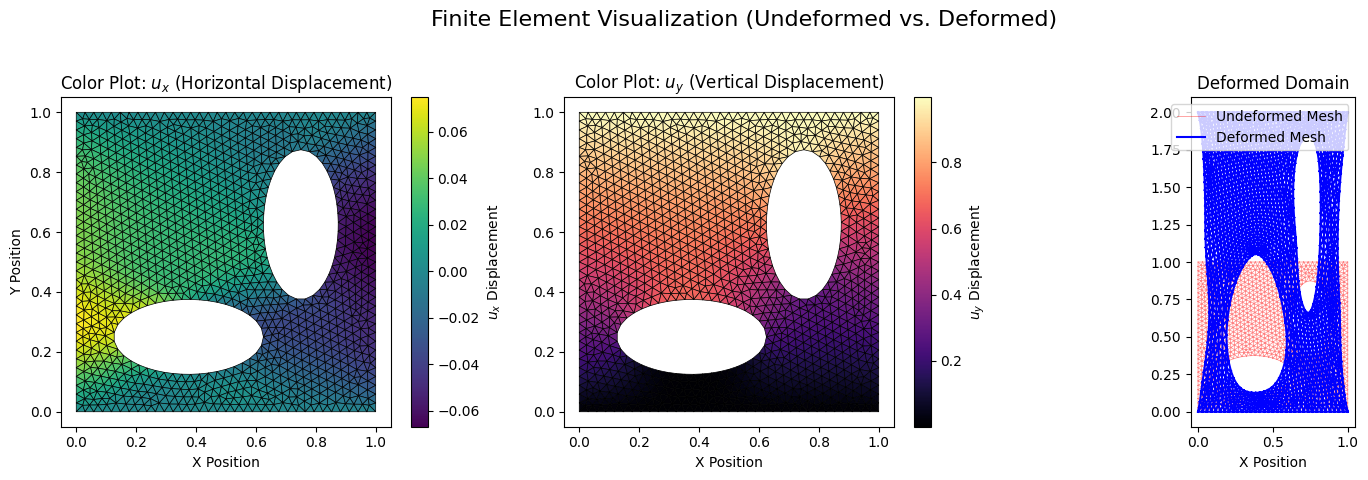

In [43]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as tri

# --- 1. Setup Dummy Data (Simulating FEM Output) ---
# Create a simple 2x2 rectangular mesh with 4 nodes and 2 triangular elements
# Node coordinates (Undeformed mesh_pos)
mesh_pos = data["mesh_pos"]

# Element connectivity (cells: indices of nodes forming each triangle)
cells = data["cells"]

# Displacement components (ux and uy) at each node
# This simulates a simple shear/tensile deformation
ux = data["u"][0][:, 0]
uy = data["u"][0][:, 1]

# Combine components into the full displacement vector u
u = np.column_stack((ux, uy))

# Calculate the deformed coordinates (world_pos)
world_pos = mesh_pos[:, :2] + u

# --- 2. Initialize Triangulation Objects ---
# We need the x and y coordinates from the undeformed mesh
x = mesh_pos[:, 0]
y = mesh_pos[:, 1]

# Create the Matplotlib Triangulation object
# This object stores the connectivity (cells) and coordinates (x, y)
triangulation = tri.Triangulation(x, y, cells)

# --- 3. Plotting ---

# Set up the figure with 1 row and 3 columns for the plots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Finite Element Visualization (Undeformed vs. Deformed)', fontsize=16)

# --- Subplot 1: Plotting UX (Horizontal Displacement) ---
ax1 = axes[0]
# tripcolor uses the triangulation to color the triangles based on the nodal value
# `facecolors` uses the average of the three nodal values per triangle for coloring
tpc1 = ax1.tripcolor(triangulation, ux, cmap='viridis', edgecolors='k', linewidth=0.5)
fig.colorbar(tpc1, ax=ax1, label='$u_x$ Displacement')
# ax1.scatter(mesh_pos[data["node_type"] == 5, 0], mesh_pos[node_type == 5, 1])
ax1.set_title('Color Plot: $u_x$ (Horizontal Displacement)')
ax1.set_xlabel('X Position')
ax1.set_ylabel('Y Position')
ax1.set_aspect('equal')

# --- Subplot 2: Plotting UY (Vertical Displacement) ---
ax2 = axes[1]
tpc2 = ax2.tripcolor(triangulation, uy, cmap='magma', edgecolors='k', linewidth=0.5)
fig.colorbar(tpc2, ax=ax2, label='$u_y$ Displacement')

ax2.set_title('Color Plot: $u_y$ (Vertical Displacement)')
ax2.set_xlabel('X Position')
ax2.set_aspect('equal')

# --- Subplot 3: Plotting Deformed Domain ---
ax3 = axes[2]

# Plot the outline of the UNDEFORMED mesh for reference (dashed gray)
ax3.triplot(triangulation, 'r-', alpha=0.5, linewidth=0.5, label='Undeformed Mesh')

# Plot the DEFORMED mesh. We must manually create a new triangulation
# object using the deformed coordinates (world_pos) but the SAME connectivity (cells).
x_def = world_pos[:, 0]
y_def = world_pos[:, 1]
tri_def = tri.Triangulation(x_def, y_def, cells)

# Plot the deformed mesh (solid blue lines)
ax3.triplot(tri_def, 'b-', linewidth=1.5, label='Deformed Mesh')

ax3.set_title('Deformed Domain')
ax3.set_xlabel('X Position')
ax3.legend()
ax3.set_aspect('equal')

# Adjust layout to prevent overlaps
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [108]:

from dolfinx import log, default_scalar_type
from dolfinx.fem.petsc import NonlinearProblem
import numpy as np
from dolfinx.io.gmsh import read_from_msh
import ufl
import gmsh
from mpi4py import MPI
from dolfinx import fem, mesh, plot
def facets_to_nodes(domain, facet_ids):
    fdim = domain.topology.dim - 1
    domain.topology.create_connectivity(fdim, 0)
    facet_to_vertices = domain.topology.connectivity(fdim, 0)
    all_nodes = []
    for f in facet_ids:
        all_nodes.extend(facet_to_vertices.links(f))
    return np.unique(np.array(all_nodes, dtype=np.int32))
def FEM_solve(load_parameter, elastic_modulus, poisson_ratio) :
    gmsh.initialize()
    gdim = 2
    model = gmsh.model.occ
    L_x = 1.0
    L_y = 1.0
    R_hole = 0.1
    mesh_size = 0.05
    load_parameter = load_parameter
    # 2. Create rectangle
    rect = model.addRectangle(0.0, 0.0, 0.0, L_x, L_y)

    # 3. Create circle
    circle1 = model.addEllipse(1 - 0.25, 1 - 0.375, 0.0, 0.125, 0.25)
    circle2 = model.addEllipse(0.375, 0.25, 0.0, 0.25, 0.125) 
    # 4. Cut the hole
    domain_with_hole, _ = model.cut([(gdim, rect)], [(gdim, circle1)], [(gdim, circle2)])
    gmsh.model.occ.synchronize()

    # 5. Physical group
    gmsh.model.addPhysicalGroup(gdim, [domain_with_hole[0][1]], 1)
    gmsh.model.setPhysicalName(gdim, 1, "domain")
    gmsh.option.setNumber("Mesh.CharacteristicLengthMin", mesh_size)
    gmsh.option.setNumber("Mesh.CharacteristicLengthMax", mesh_size)
    gmsh.model.mesh.generate(gdim)
    # 6. Mesh generation
    gmsh.model.mesh.generate(gdim)

    # 7. Write to file
    gmsh.write("mesh_with_hole.msh")
    gmsh.finalize()

    # 8. Read into DOLFINx
    mesh_ = read_from_msh("mesh_with_hole.msh", MPI.COMM_WORLD, 0, gdim)
    domain = mesh_.mesh
    V = fem.functionspace(domain, ("Lagrange", 1, (domain.geometry.dim,)))


    # -

    # We create two python functions for determining the facets to apply boundary conditions to


    # +
    def left(x):
        return np.isclose(x[0], 0)


    def right(x):
        return np.isclose(x[0], L_x)


    def top(x):
        return np.isclose(x[1], L_y)


    def bottom(x):
        return np.isclose(x[1], 0) 

    fdim = domain.topology.dim - 1
    left_facets = mesh.locate_entities_boundary(domain, fdim, left)
    right_facets = mesh.locate_entities_boundary(domain, fdim, right)
    top_facets = mesh.locate_entities_boundary(domain, fdim, top)
    bottom_facets = mesh.locate_entities_boundary(domain, fdim, bottom)
    # -

    # Next, we create a  marker based on these two functions

    # Concatenate and sort the arrays based on facet indices. Left facets marked with 1, right facets with two

    marked_facets = np.hstack([left_facets, bottom_facets, right_facets, top_facets])
    marked_values = np.hstack([np.full_like(left_facets, 1), np.full_like(bottom_facets, 2), np.full_like(right_facets, 3), np.full_like(top_facets, 4)])
    sorted_facets = np.argsort(marked_facets)
    facet_tag = mesh.meshtags(
        domain, fdim, marked_facets[sorted_facets], marked_values[sorted_facets]
    )

    # We then create a function for supplying the boundary condition on the left side, which is fixed.

    u_bc = np.array((0,) * domain.geometry.dim, dtype=default_scalar_type)

    # To apply the boundary condition, we identity the dofs located on the facets marked by the `MeshTag`.
    zero = fem.Constant(domain, default_scalar_type(0.0))
    control_ux = fem.Constant(domain, default_scalar_type(0.0))
    control_uy = fem.Constant(domain, default_scalar_type(load_parameter))

    # Locate DOFs (note the use of collapsed spaces)
    left_dofs = fem.locate_dofs_topological(V.sub(0), facet_tag.dim, facet_tag.find(1))
    bottom_dofs = fem.locate_dofs_topological(V.sub(1), facet_tag.dim, facet_tag.find(2))
    right_dofs = fem.locate_dofs_topological(V.sub(0), facet_tag.dim, facet_tag.find(3))
    top_dofs = fem.locate_dofs_topological(V.sub(1), facet_tag.dim, facet_tag.find(4))
    bcs = [fem.dirichletbc(zero, left_dofs, V.sub(0)), 
        fem.dirichletbc(zero, bottom_dofs, V.sub(1)),
        fem.dirichletbc(control_uy, top_dofs, V.sub(1))]

    # Next, we define the body force on the reference configuration (`B`), and nominal (first Piola-Kirchhoff) traction (`T`).

    B = fem.Constant(domain, default_scalar_type((0, 0)))
    T = fem.Constant(domain, default_scalar_type((0, 0)))

    # Define the test and solution functions on the space $V$

    v = ufl.TestFunction(V)
    u = fem.Function(V)

    # Define kinematic quantities used in the problem

    # +
    # Spatial dimension
    d = len(u)

    # Identity tensor
    I = ufl.variable(ufl.Identity(d))

    # Deformation gradient
    F = ufl.variable(I + ufl.grad(u))

    # Right Cauchy-Green tensor
    C = ufl.variable(F.T * F)

    # Invariants of deformation tensors
    Ic = ufl.variable(ufl.tr(C))
    J = ufl.variable(ufl.det(F))
    # -

    # Define the elasticity model via a stored strain energy density function $\psi$,
    # and create the expression for the first Piola-Kirchhoff stress:

    # Elasticity parameters

    E = default_scalar_type(elastic_modulus)
    nu = default_scalar_type(poisson_ratio)
    mu = fem.Constant(domain, E / (2 * (1 + nu)))
    lmbda = fem.Constant(domain, E * nu / ((1 + nu) * (1 - 2 * nu)))

    # Stored strain energy density (compressible neo-Hookean model)

    # psi = (mu / 2) * (Ic - 3) - mu * ufl.ln(J) + (lmbda / 2) * (ufl.ln(J)) ** 2

    psi = 0.5 * (J**(-2/3) * Ic - 3) + 1.5 * (J - 1)**2
    # Hyper-elasticity

    P = ufl.diff(psi, F)

    metadata = {"quadrature_degree": 4}
    ds = ufl.Measure("ds", domain=domain, subdomain_data=facet_tag, metadata=metadata)
    dx = ufl.Measure("dx", domain=domain, metadata=metadata)

    # Define the residual of the equation (we want to find u such that residual(u) = 0)

    residual = (
        ufl.inner(ufl.grad(v), P) * dx - ufl.inner(v, B) * dx - ufl.inner(v, T) * ds(3)
    )

    # As the varitional form is non-linear and written on residual form,
    # we use the non-linear problem class from DOLFINx to set up required structures to use a Newton solver.

    petsc_options = {
        "snes_type": "newtonls",
        "snes_linesearch_type": "none",
        "snes_monitor": None,
        "snes_atol": 1e-10,
        "snes_rtol": 1e-10,
        "snes_stol": 1e-10,
        "ksp_type": "preonly",
        "pc_type": "lu",
        "pc_factor_mat_solver_type": "mumps",
    }
    problem = NonlinearProblem(
        residual,
        u,
        bcs=bcs,
        petsc_options=petsc_options,
        petsc_options_prefix="hyperelasticity",
        
    )

    problem.solve()


    mesh_pos = domain.geometry.x
    fdim = domain.topology.dim - 1 
    domain.topology.create_connectivity(fdim, domain.topology.dim)
    cells = domain.topology.connectivity(domain.topology.dim, 0).array.reshape(-1, 3)
    u_array = u.x.array[:].reshape(mesh_pos.shape[0], -1)
    num_nodes = domain.geometry.x.shape[0]
    node_type = np.zeros(num_nodes, dtype=int)
    node_type[facets_to_nodes(domain, left_facets)] = 1
    node_type[facets_to_nodes(domain, bottom_facets)] = 2
    node_type[facets_to_nodes(domain, right_facets)] = 3
    node_type[facets_to_nodes(domain, top_facets)] = 4

    return dict(mesh_pos = mesh_pos, cells = cells, u = u_array, node_type = node_type, load_parameter = load_parameter)


In [7]:
data = FEM_solve(0.5, 1e4, 0.2)

Error   : Major radius rx should be larger than minor radius ry


Exception: Major radius rx should be larger than minor radius ry

In [2]:

import ufl

In [ ]:
    # Deformation gradient
I = ufl.variable(ufl.Identity(2))
F = ufl.variable(I)

    # Right Cauchy-Green tensor
C = ufl.variable(F.T * F)

    # Invariants of deformation tensors
Ic = ufl.variable(ufl.tr(C))
Ic

In [ ]:
Ic

TypeError: Variable.evaluate() missing 4 required positional arguments: 'x', 'mapping', 'component', and 'index_values'

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as tri

# --- 1. Setup Dummy Data (Simulating FEM Output) ---
# Create a simple 2x2 rectangular mesh with 4 nodes and 2 triangular elements
# Node coordinates (Undeformed mesh_pos)
mesh_pos = data["mesh_pos"]

# Element connectivity (cells: indices of nodes forming each triangle)
cells = data["cells"]

# Displacement components (ux and uy) at each node
# This simulates a simple shear/tensile deformation
ux = data["u"][:, 0]
uy = data["u"][:, 1]

# Combine components into the full displacement vector u
u = np.column_stack((ux, uy))

# Calculate the deformed coordinates (world_pos)
world_pos = mesh_pos[:, :2] + u

# --- 2. Initialize Triangulation Objects ---
# We need the x and y coordinates from the undeformed mesh
x = mesh_pos[:, 0]
y = mesh_pos[:, 1]

# Create the Matplotlib Triangulation object
# This object stores the connectivity (cells) and coordinates (x, y)
triangulation = tri.Triangulation(x, y, cells)

# --- 3. Plotting ---

# Set up the figure with 1 row and 3 columns for the plots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Finite Element Visualization (Undeformed vs. Deformed)', fontsize=16)

# --- Subplot 1: Plotting UX (Horizontal Displacement) ---
ax1 = axes[0]
# tripcolor uses the triangulation to color the triangles based on the nodal value
# `facecolors` uses the average of the three nodal values per triangle for coloring
tpc1 = ax1.tripcolor(triangulation, ux, cmap='viridis', edgecolors='k', linewidth=0.5)
fig.colorbar(tpc1, ax=ax1, label='$u_x$ Displacement')
# ax1.scatter(mesh_pos[data["node_type"] == 5, 0], mesh_pos[node_type == 5, 1])
ax1.set_title('Color Plot: $u_x$ (Horizontal Displacement)')
ax1.set_xlabel('X Position')
ax1.set_ylabel('Y Position')
ax1.set_aspect('equal')

# --- Subplot 2: Plotting UY (Vertical Displacement) ---
ax2 = axes[1]
tpc2 = ax2.tripcolor(triangulation, uy, cmap='magma', edgecolors='k', linewidth=0.5)
fig.colorbar(tpc2, ax=ax2, label='$u_y$ Displacement')

ax2.set_title('Color Plot: $u_y$ (Vertical Displacement)')
ax2.set_xlabel('X Position')
ax2.set_aspect('equal')

# --- Subplot 3: Plotting Deformed Domain ---
ax3 = axes[2]

# Plot the outline of the UNDEFORMED mesh for reference (dashed gray)
ax3.triplot(triangulation, 'r-', alpha=0.5, linewidth=0.5, label='Undeformed Mesh')

# Plot the DEFORMED mesh. We must manually create a new triangulation
# object using the deformed coordinates (world_pos) but the SAME connectivity (cells).
x_def = world_pos[:, 0]
y_def = world_pos[:, 1]
tri_def = tri.Triangulation(x_def, y_def, cells)

# Plot the deformed mesh (solid blue lines)
ax3.triplot(tri_def, 'b-', linewidth=1.5, label='Deformed Mesh')

ax3.set_title('Deformed Domain')
ax3.set_xlabel('X Position')
ax3.legend()
ax3.set_aspect('equal')

# Adjust layout to prevent overlaps
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

NameError: name 'data' is not defined

In [23]:
import numpy as np
import csv
import pandas as pd
import os

In [ ]:
mat_model_path = "dataset/benchmarks//Isihara-GT"
load_step = 5
files_path = os.path.join(mat_model_path, str(load_step))
files = os.listdir(files_path)
data = dict()
for f in files :
    if f.endswith(".csv") :
        data[f"{f.rstrip(".csv")}"] = pd.read_csv(files_path + "/" + f)

In [25]:
mesh_pos = data["output_node"][["x", "y"]].to_numpy()
u = data["output_node"][["ux", "uy"]].to_numpy()
cells = data["output_element"][["node1", "node2", "node3"]].to_numpy()

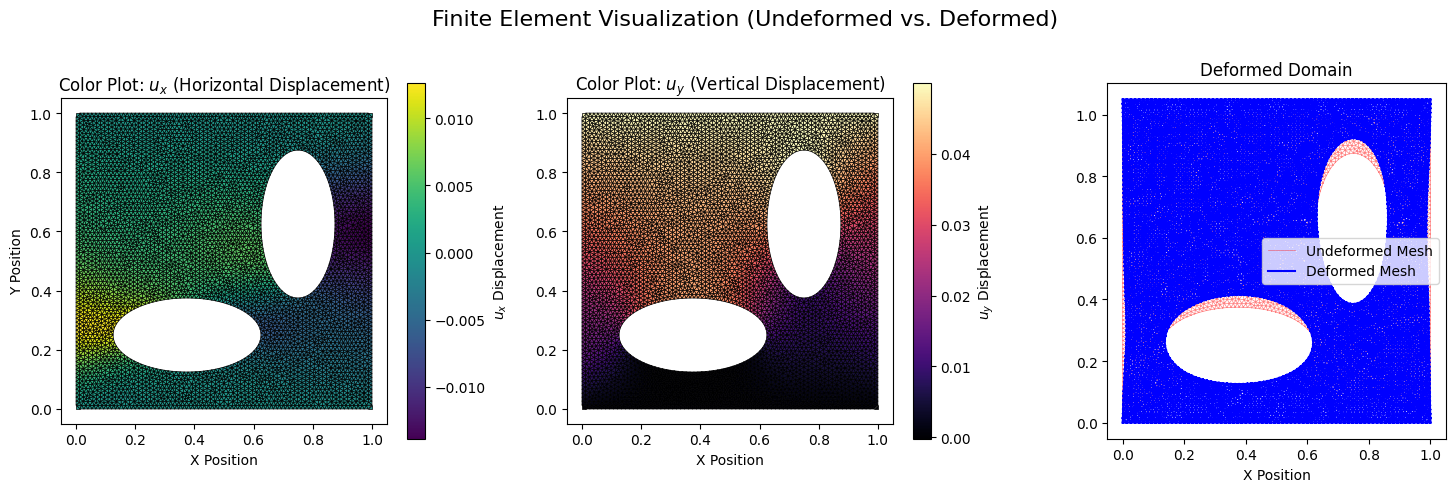

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as tri

# --- 1. Setup Dummy Data (Simulating FEM Output) ---
# Create a simple 2x2 rectangular mesh with 4 nodes and 2 triangular elements
# Node coordinates (Undeformed mesh_pos)
mesh_pos = mesh_pos

# Element connectivity (cells: indices of nodes forming each triangle)
cells = cells

# Displacement components (ux and uy) at each node
# This simulates a simple shear/tensile deformation
ux = u[:, 0]
uy = u[:, 1]

# Combine components into the full displacement vector u
u = np.column_stack((ux, uy))

# Calculate the deformed coordinates (world_pos)
world_pos = mesh_pos[:, :2] + u

# --- 2. Initialize Triangulation Objects ---
# We need the x and y coordinates from the undeformed mesh
x = mesh_pos[:, 0]
y = mesh_pos[:, 1]

# Create the Matplotlib Triangulation object
# This object stores the connectivity (cells) and coordinates (x, y)
triangulation = tri.Triangulation(x, y, cells)

# --- 3. Plotting ---

# Set up the figure with 1 row and 3 columns for the plots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Finite Element Visualization (Undeformed vs. Deformed)', fontsize=16)

# --- Subplot 1: Plotting UX (Horizontal Displacement) ---
ax1 = axes[0]
# tripcolor uses the triangulation to color the triangles based on the nodal value
# `facecolors` uses the average of the three nodal values per triangle for coloring
tpc1 = ax1.tripcolor(triangulation, ux, cmap='viridis', edgecolors='k', linewidth=0.5)
fig.colorbar(tpc1, ax=ax1, label='$u_x$ Displacement')
# ax1.scatter(mesh_pos[data["node_type"] == 5, 0], mesh_pos[node_type == 5, 1])
ax1.set_title('Color Plot: $u_x$ (Horizontal Displacement)')
ax1.set_xlabel('X Position')
ax1.set_ylabel('Y Position')
ax1.set_aspect('equal')

# --- Subplot 2: Plotting UY (Vertical Displacement) ---
ax2 = axes[1]
tpc2 = ax2.tripcolor(triangulation, uy, cmap='magma', edgecolors='k', linewidth=0.5)
fig.colorbar(tpc2, ax=ax2, label='$u_y$ Displacement')

ax2.set_title('Color Plot: $u_y$ (Vertical Displacement)')
ax2.set_xlabel('X Position')
ax2.set_aspect('equal')

# --- Subplot 3: Plotting Deformed Domain ---
ax3 = axes[2]

# Plot the outline of the UNDEFORMED mesh for reference (dashed gray)
ax3.triplot(triangulation, 'r-', alpha=0.5, linewidth=0.5, label='Undeformed Mesh')

# Plot the DEFORMED mesh. We must manually create a new triangulation
# object using the deformed coordinates (world_pos) but the SAME connectivity (cells).
x_def = world_pos[:, 0]
y_def = world_pos[:, 1]
tri_def = tri.Triangulation(x_def, y_def, cells)

# Plot the deformed mesh (solid blue lines)
ax3.triplot(tri_def, 'b-', linewidth=1.5, label='Deformed Mesh')

ax3.set_title('Deformed Domain')
ax3.set_xlabel('X Position')
ax3.legend()
ax3.set_aspect('equal')

# Adjust layout to prevent overlaps
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [116]:
mat_model_path = "/home/mmdiscovery/shared/ref/EUCLID-hyperelasticity-NN/fem-data/noise=high/NeoHookean"
load_step = 10
files_path = os.path.join(mat_model_path, str(load_step))
files = os.listdir(files_path)
data = dict()
for f in files :
    if f.endswith(".csv") :
        data[f"{f.rstrip(".csv")}"] = pd.read_csv(files_path + "/" + f)

In [117]:
mesh_pos = data["output_node"][["x", "y"]].to_numpy()
u = data["output_node"][["ux", "uy"]].to_numpy()
cells = data["output_element"][["node1", "node2", "node3"]].to_numpy()

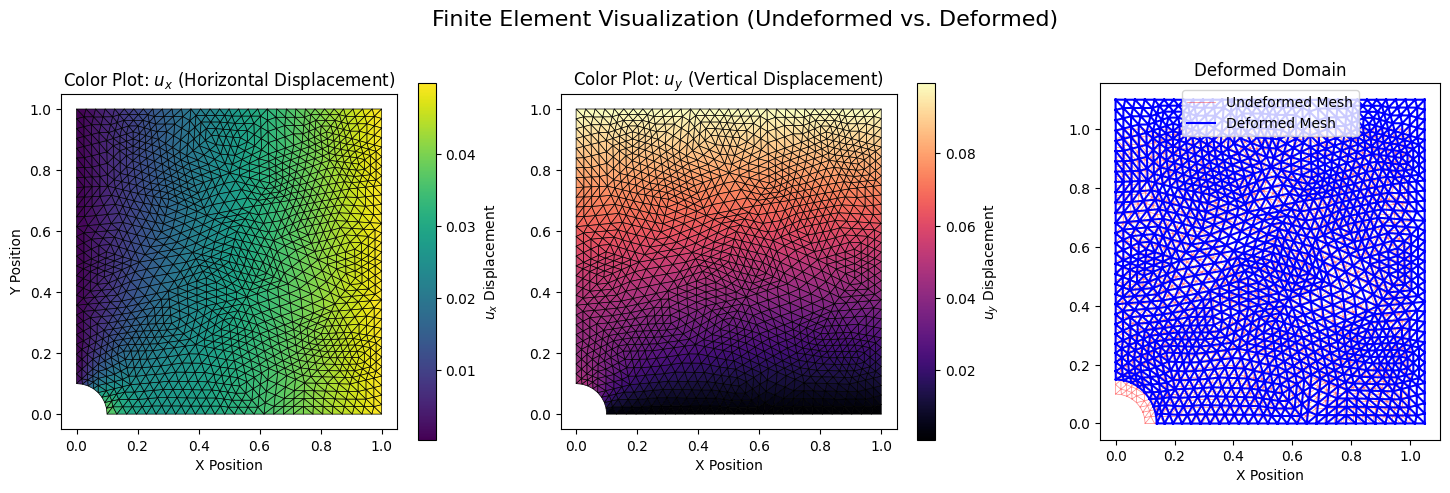

In [118]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as tri

# --- 1. Setup Dummy Data (Simulating FEM Output) ---
# Create a simple 2x2 rectangular mesh with 4 nodes and 2 triangular elements
# Node coordinates (Undeformed mesh_pos)
mesh_pos = mesh_pos

# Element connectivity (cells: indices of nodes forming each triangle)
cells = cells

# Displacement components (ux and uy) at each node
# This simulates a simple shear/tensile deformation
ux = u[:, 0]
uy = u[:, 1]

# Combine components into the full displacement vector u
u = np.column_stack((ux, uy))

# Calculate the deformed coordinates (world_pos)
world_pos = mesh_pos[:, :2] + u

# --- 2. Initialize Triangulation Objects ---
# We need the x and y coordinates from the undeformed mesh
x = mesh_pos[:, 0]
y = mesh_pos[:, 1]

# Create the Matplotlib Triangulation object
# This object stores the connectivity (cells) and coordinates (x, y)
triangulation = tri.Triangulation(x, y, cells)

# --- 3. Plotting ---

# Set up the figure with 1 row and 3 columns for the plots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Finite Element Visualization (Undeformed vs. Deformed)', fontsize=16)

# --- Subplot 1: Plotting UX (Horizontal Displacement) ---
ax1 = axes[0]
# tripcolor uses the triangulation to color the triangles based on the nodal value
# `facecolors` uses the average of the three nodal values per triangle for coloring
tpc1 = ax1.tripcolor(triangulation, ux, cmap='viridis', edgecolors='k', linewidth=0.5)
fig.colorbar(tpc1, ax=ax1, label='$u_x$ Displacement')
# ax1.scatter(mesh_pos[data["node_type"] == 5, 0], mesh_pos[node_type == 5, 1])
ax1.set_title('Color Plot: $u_x$ (Horizontal Displacement)')
ax1.set_xlabel('X Position')
ax1.set_ylabel('Y Position')
ax1.set_aspect('equal')

# --- Subplot 2: Plotting UY (Vertical Displacement) ---
ax2 = axes[1]
tpc2 = ax2.tripcolor(triangulation, uy, cmap='magma', edgecolors='k', linewidth=0.5)
fig.colorbar(tpc2, ax=ax2, label='$u_y$ Displacement')

ax2.set_title('Color Plot: $u_y$ (Vertical Displacement)')
ax2.set_xlabel('X Position')
ax2.set_aspect('equal')

# --- Subplot 3: Plotting Deformed Domain ---
ax3 = axes[2]

# Plot the outline of the UNDEFORMED mesh for reference (dashed gray)
ax3.triplot(triangulation, 'r-', alpha=0.5, linewidth=0.5, label='Undeformed Mesh')

# Plot the DEFORMED mesh. We must manually create a new triangulation
# object using the deformed coordinates (world_pos) but the SAME connectivity (cells).
x_def = world_pos[:, 0]
y_def = world_pos[:, 1]
tri_def = tri.Triangulation(x_def, y_def, cells)

# Plot the deformed mesh (solid blue lines)
ax3.triplot(tri_def, 'b-', linewidth=1.5, label='Deformed Mesh')

ax3.set_title('Deformed Domain')
ax3.set_xlabel('X Position')
ax3.legend()
ax3.set_aspect('equal')

# Adjust layout to prevent overlaps
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [119]:
data["output_element"]

,node1,node2,node3,Fxx,Fxy,Fyx,Fyy,Pxx,Pxy,Pyx,Pyy
0,144,441,443,1.049492,-0.005056,-0.006112,1.093069,0.484786,-0.007258,-0.007765,0.543405
1,441,442,443,1.049634,-0.005354,-0.006489,1.093861,0.488024,-0.007667,-0.008215,0.547334
2,441,199,442,1.049465,-0.005670,-0.006927,1.093040,0.484523,-0.008174,-0.008776,0.543153
3,443,442,201,1.048886,-0.005069,-0.006149,1.093732,0.484025,-0.007285,-0.007804,0.544347
4,199,444,442,1.049632,-0.006021,-0.007349,1.093926,0.488182,-0.008643,-0.009284,0.547571
...,...,...,...,...,...,...,...,...,...,...,...
2747,1439,1437,440,1.051317,-0.031698,-0.034755,1.094069,0.491775,-0.043712,-0.045195,0.548972
2748,381,1440,1127,1.044330,-0.029265,-0.033096,1.102115,0.484874,-0.040672,-0.042540,0.561980
2749,1440,1436,1127,1.042547,-0.030118,-0.037863,1.099836,0.467939,-0.044185,-0.047849,0.545497
2750,1440,440,1436,1.047359,-0.033388,-0.036809,1.099120,0.488575,-0.046013,-0.047680,0.557661


In [32]:
import jax.numpy as jnp

In [33]:
x = jnp.array([[1,2],[3,4]])
def F2x2_to_F3x3(f):
    # f: (..., 2, 2)
    batch_shape = f.shape[:-2]

    # Start with identity matrices of the right batch shape
    out = jnp.broadcast_to(jnp.eye(3), batch_shape + (3, 3)).copy()

    # Insert the 2×2 blocks
    out = out.at[..., :2, :2].set(f)
    return out

In [34]:
F2x2_to_F3x3(x)

Array([[1., 2., 0.],
       [3., 4., 0.],
       [0., 0., 1.]], dtype=float32)

In [38]:

from dolfinx import log, default_scalar_type
from dolfinx.fem.petsc import NonlinearProblem
import numpy as np
from dolfinx.io.gmsh import read_from_msh
import ufl
import gmsh
from petsc4py import PETSc
from mpi4py import MPI
from dolfinx import fem, mesh, plot
from dolfinx_materials.jax_materials.hyperelasticity import IsiharaMaterial
from dolfinx_materials.quadrature_map import QuadratureMap
from dolfinx_materials.jax_materials import IsiharaMaterial
from dolfinx_materials.solvers import NonlinearMaterialProblem
from dolfinx_materials.utils import nonsymmetric_tensor_to_vector, project

def facets_to_nodes(domain, facet_ids):
    fdim = domain.topology.dim - 1
    domain.topology.create_connectivity(fdim, 0)
    facet_to_vertices = domain.topology.connectivity(fdim, 0)
    all_nodes = []
    for f in facet_ids:
        all_nodes.extend(facet_to_vertices.links(f))
    return np.unique(np.array(all_nodes, dtype=np.int32))
def FEM_solve(load_parameter, elastic_modulus, poisson_ratio) :
    gmsh.initialize()
    gdim = 2
    model = gmsh.model.occ
    L_x = 1.0
    L_y = 1.0
    R_hole = 0.1
    mesh_size = 0.03
    load_parameter = load_parameter
    # 2. Create rectangle
    rect = model.addRectangle(0.0, 0.0, 0.0, L_x, L_y)

    # 3. Create circle
    ellipses = [
        (0.375, 0.25, 0.25, 0.125),   # ellipse 1
        (0.75, 1 - 0.375, 0.125, 0.25),  # ellipse 2
    ]

    # ellipse_objs = []
    ellipse_faces = []
    for (cx, cy, rx, ry) in ellipses:
        
        if rx < ry :
            disk = model.addDisk(cx, cy, 0.0, ry, rx)  # make a filled 2D region
            model.rotate([(gdim, disk)], cx, cy, 0, 0, 0, 1, np.pi/2)
        else :
            disk = model.addDisk(cx, cy, 0.0, rx, ry)  # make a filled 2D region
        ellipse_faces.append((gdim, disk))
    # print(gdim, ellipse1)
    # --- Cut both ellipses from the rectangle ---
    domain_with_holes, _ = model.cut([(gdim, rect)], ellipse_faces)

    # --- Synchronize geometry ---
    model.synchronize()

    # 5. Physical group
    gmsh.model.addPhysicalGroup(gdim, [domain_with_holes[0][1]], 1)
    gmsh.model.setPhysicalName(gdim, 1, "domain")
    gmsh.option.setNumber("Mesh.CharacteristicLengthMin", mesh_size)
    gmsh.option.setNumber("Mesh.CharacteristicLengthMax", mesh_size)
    gmsh.model.mesh.generate(gdim)
    # 6. Mesh generation
    gmsh.model.mesh.generate(gdim)

    # 7. Write to file
    gmsh.write("mesh_with_hole.msh")
    gmsh.finalize()

    # 8. Read into DOLFINx
    mesh_ = read_from_msh("mesh_with_hole.msh", MPI.COMM_WORLD, 0, gdim)
    domain = mesh_.mesh
    V = fem.functionspace(domain, ("Lagrange", 1, (domain.geometry.dim,)))


    # -

    # We create two python functions for determining the facets to apply boundary conditions to


    # +
    def left(x):
        return np.isclose(x[0], 0)


    def right(x):
        return np.isclose(x[0], L_x)


    def top(x):
        return np.isclose(x[1], L_y)


    def bottom(x):
        return np.isclose(x[1], 0)


    fdim = domain.topology.dim - 1
    left_facets = mesh.locate_entities_boundary(domain, fdim, left)
    right_facets = mesh.locate_entities_boundary(domain, fdim, right)
    top_facets = mesh.locate_entities_boundary(domain, fdim, top)
    bottom_facets = mesh.locate_entities_boundary(domain, fdim, bottom)
    # -

    # Next, we create a  marker based on these two functions

    # Concatenate and sort the arrays based on facet indices. Left facets marked with 1, right facets with two

    marked_facets = np.hstack([left_facets, bottom_facets, right_facets, top_facets])
    marked_values = np.hstack([np.full_like(left_facets, 1), np.full_like(bottom_facets, 2), np.full_like(right_facets, 3), np.full_like(top_facets, 4)])
    sorted_facets = np.argsort(marked_facets)
    facet_tag = mesh.meshtags(
        domain, fdim, marked_facets[sorted_facets], marked_values[sorted_facets]
    )

    # We then create a function for supplying the boundary condition on the left side, which is fixed.

    u_bc = np.array((0,) * domain.geometry.dim, dtype=default_scalar_type)

    # To apply the boundary condition, we identity the dofs located on the facets marked by the `MeshTag`.
    zero = fem.Constant(domain, default_scalar_type(0.0))
    # control_ux = fem.Constant(domain, default_scalar_type(load_parameter * 0))
    control_uy = fem.Constant(domain, default_scalar_type(0.1))

    # Locate DOFs (note the use of collapsed spaces)
    # left_dofs = fem.locate_dofs_topological(V.sub(0), facet_tag.dim, facet_tag.find(1))
    bottom_dofs = fem.locate_dofs_topological(V, facet_tag.dim, facet_tag.find(2))
    # bottom_y_dofs = fem.locate_dofs_topological(V.sub(1), facet_tag.dim, facet_tag.find(2))
    # right_dofs = fem.locate_dofs_topological(V.sub(0), facet_tag.dim, facet_tag.find(3))
    top_y_dof = fem.locate_dofs_topological(V.sub(1), facet_tag.dim, facet_tag.find(4))
    top_x_dof = fem.locate_dofs_topological(V.sub(0), facet_tag.dim, facet_tag.find(4))
    bcs = [
        fem.dirichletbc(u_bc, bottom_dofs, V),
        fem.dirichletbc(control_uy, top_y_dof, V.sub(1)),
        fem.dirichletbc(zero, top_x_dof, V.sub(0))
        ]

    # Next, we define the body force on the reference configuration (`B`), and nominal (first Piola-Kirchhoff) traction (`T`).

    B = fem.Constant(domain, default_scalar_type((0, 0)))
    T = fem.Constant(domain, default_scalar_type((0, 0)))

    # Define the test and solution functions on the space $V$

    v = ufl.TestFunction(V)
    u = fem.Function(V)
    du = ufl.TrialFunction(V)
    # Define kinematic quantities used in the problem

    # +
    # Spatial dimension
    d = len(u)

    # Identity tensor
    I = ufl.variable(ufl.Identity(3))

    # Deformation gradient
    def grad_3D(u):
        return ufl.as_matrix([[u[0].dx(0), u[0].dx(1), 0], 
                            [u[1].dx(0), u[1].dx(1), 0], 
                            [0, 0, 0]])
    F = ufl.variable(I + grad_3D(u))

    # Right Cauchy-Green tensor
    C = ufl.variable(F.T * F)
    b = ufl.variable(F * F.T)
    # Invariants of deformation tensors
    I1 = ufl.variable(ufl.tr(C))
    I2 = ufl.variable(0.5 * (ufl.tr(C)**2 - ufl.tr(C * C)))
    # I1 = ufl.variable(ufl.tr(b))
    # I2 = ufl.variable(0.5 * (ufl.tr(b)**2 - ufl.tr(b * b)))
    J = ufl.variable(ufl.det(F))
    I3 = J**2
    # -

    # Define the elasticity model via a stored strain energy density function $\psi$,
    # and create the expression for the first Piola-Kirchhoff stress:

    # Elasticity parameters

    E = default_scalar_type(elastic_modulus)
    nu = default_scalar_type(poisson_ratio)
    mu = fem.Constant(domain, E / (2 * (1 + nu)))
    lmbda = fem.Constant(domain, E * nu / ((1 + nu) * (1 - 2 * nu)))

    # Stored strain energy density (compressible neo-Hookean model)

    # psi = (mu / 2) * (Ic - 3) - mu * ufl.ln(J) + (lmbda / 2) * (ufl.ln(J)) ** 2
    # def MooneyRivlinPhi(I1, I2, I3):
    #     # c1, c2, c3 = 1.0, 0.001, 1000
    #     c1, c2, c3 = 0.162, 0.0059, 10
    #     term1 = c1 * (I3**(-0.5) * I1 - 3)
    #     term2 = c2 * (I3**(-2/3) * I2 - 3)
    #     term3 = c3 * (I3**0.5 - 1)**2
    #     return term1 + term2 + term3  # [N]
    # psi = MooneyRivlinPhi(I1, I2, I3)
    # psi = 0.5 * (J**(-2/3) * I1 - 2) + 1.5 * (J - 1)**2
    # psi = 0.5 * (J**(-2/3) * I1 - 3) + (J**(-4/3) * I2 - 3) +(J**(-2/3) * I1 - 3)**2 + 1.5 * (J - 1)**2
    # psi = 0.5 * (J**(-2/3) * I1 - 3) + ufl.ln(J**(-4/3) * I2/3) + 1.5 * (J - 1)**2
    # Hyper-elasticity
    material = IsiharaMaterial()
    qmap = QuadratureMap(domain, 1, material)
    # P = ufl.diff(psi, F)
    Id2 = ufl.Identity(2)

    def F_2d_to_3d(u_):
        F_2d = Id2 + ufl.grad(u_)
        F_3d = ufl.as_matrix([[F_2d[0,0], F_2d[0,1], 0],[F_2d[1,0], F_2d[1,1], 0],[0,0,1]])
        return nonsymmetric_tensor_to_vector(F_3d)
    def dF(u_, v_):
        return ufl.derivative(F_2d_to_3d(u_), u_, v_)
    # metadata = {"quadrature_degree": 4}
    # ds = ufl.Measure("ds", domain=domain, subdomain_data=facet_tag, metadata=metadata)
    # dx = ufl.Measure("dx", domain=domain, metadata=metadata)
    qmap.register_gradient("F", F_2d_to_3d(u))

    dx = ufl.Measure("dx", metadata={"quadrature_degree": 1}, domain=domain)
    P = qmap.fluxes["PK1"]
    Res = ufl.inner(P, dF(u, v)) * dx
    Jac = qmap.derivative(Res, u, du)
    qmap.initialize_state(); qmap.update()
    # Define the residual of the equation (we want to find u such that residual(u) = 0)

    # residual = (
    #     ufl.inner(grad_3D(v), P) * dx - ufl.inner(v, B) * dx - ufl.inner(v, T) * ds(3)
    # )

    # As the varitional form is non-linear and written on residual form,
    # we use the non-linear problem class from DOLFINx to set up required structures to use a Newton solver.

    petsc_options = {
        "snes_type": "newtonls",
        "snes_linesearch_type": "bt",
        "snes_monitor": None,
        "snes_atol": 1e-8,
        "snes_rtol": 1e-8,
        "snes_stol": 1e-8,
        "ksp_type": "preonly",
        "pc_type": "lu",
        "pc_factor_mat_solver_type": "mumps",
    }
    # petsc_options = {"ksp_type": "preonly",
    #                  "pc_type": "lu",
    #                  "pc_factor_mat_solver_type": "mumps",
    #                  "snes_linesearch_type": "bt",
    #                  "snes_error_if_not_converged": True,
    #                  "ksp_error_if_not_converged": True
    # }
    problem = NonlinearMaterialProblem(qmap, Res, Jac, u, bcs)
    from dolfinx.nls.petsc import NewtonSolver
    solver = NewtonSolver(MPI.COMM_WORLD, problem)
    solver.rtol = 1e-8; solver.atol = 1e-8; solver.max_it = 100; solver.report = True
    ksp = solver.krylov_solver
    opts = PETSc.Options()
    opts["ksp_type"] = "preonly"; opts["pc_type"] = "lu"; opts["pc_factor_mat_solver_type"] = "mumps"
    ksp.setFromOptions()

    print("\nSolving nonlinear problem (continuation step)...")
    converged, nit = problem.solve(solver)
    if not converged:
        print(f"✗ Did not converge after {nit} iterations")
        return None, domain
    print(f"✓ Converged in {nit} iterations")
    # problem = NonlinearProblem(
    #     residual,
    #     u,
    #     bcs=bcs,
    #     petsc_options=petsc_options,
    #     petsc_options_prefix="hyperelasticity",
        
    # )
    # mesh_pos = domain.geometry.x
    # u_list = []
    # for step in np.linspace(0.5, 1.0, 10) :
    #     control_uy.value = step
    #     problem.solve()
    #     u_array = u.x.array[:].reshape(mesh_pos.shape[0], -1)
    #     u_list.append(u_array.copy())


    # fdim = domain.topology.dim - 1 
    # domain.topology.create_connectivity(fdim, domain.topology.dim)
    # cells = domain.topology.connectivity(domain.topology.dim, 0).array.reshape(-1, 3)
    # num_nodes = domain.geometry.x.shape[0]
    # node_type = np.zeros(num_nodes, dtype=int)
    # node_type[facets_to_nodes(domain, left_facets)] = 1
    # node_type[facets_to_nodes(domain, bottom_facets)] = 2
    # node_type[facets_to_nodes(domain, right_facets)] = 3
    # node_type[facets_to_nodes(domain, top_facets)] = 4


    # return dict(mesh_pos = mesh_pos, cells = cells, u = u_list, node_type = node_type, load_parameter = load_parameter)


In [39]:
FEM_solve(0.2, 0.1, 0.5)

Info    : Meshing 1D...
Info    : [  0%] Meshing curve 5 (Ellipse)
Info    : [ 20%] Meshing curve 6 (Ellipse)
Info    : [ 40%] Meshing curve 7 (Line)
Info    : [ 60%] Meshing curve 8 (Line)
Info    : [ 70%] Meshing curve 9 (Line)
Info    : [ 90%] Meshing curve 10 (Line)
Info    : Done meshing 1D (Wall 0.0192659s, CPU 0.020753s)
Info    : Meshing 2D...
Info    : Meshing surface 1 (Plane, Frontal-Delaunay)
Info    : Done meshing 2D (Wall 0.0341184s, CPU 0.032508s)
Info    : 1220 nodes 2448 elements
Info    : Meshing 2D...
Info    : Meshing surface 1 (Plane, Frontal-Delaunay)
Info    : Done meshing 2D (Wall 0.030049s, CPU 0.028666s)
Info    : 1220 nodes 2448 elements
Info    : Writing 'mesh_with_hole.msh'...
Info    : Done writing 'mesh_with_hole.msh'
Info    : Reading 'mesh_with_hole.msh'...
Info    : 13 entities
Info    : 1220 nodes
Info    : 2224 elements
Info    : Done reading 'mesh_with_hole.msh'


/tmp/ipykernel_82560/2379214253.py:186: RuntimeWarning: divide by zero encountered in scalar divide
  lmbda = fem.Constant(domain, E * nu / ((1 + nu) * (1 - 2 * nu)))


AttributeError: property 'u' of 'NonlinearMaterialProblem' object has no setter